# CAP 417: Hands-on 04. Multimodality, KDE, and Cullen-Frey Space
## Benchmark between *Claude Code* and *Gemini CLI*

**Course:** CAP 417, Computational Statistics, Part C
**Hands-on:** 04. Multimodality, KDE, and the Cullen-Frey Space
**Author:** Rian Koja (top-level orchestrator notebook)

This notebook is a **self-contained academic deliverable**. It collects, validates and critically compares the outputs of two independent agents (`claude-code` and `gemini-cli`) that were asked to solve the same hands-on exercise. The two `outputs/` directories are treated as immutable evidence; this notebook never regenerates them.

Every required figure, every required statistic, every required discussion question, and the explicit benchmark between agents are presented below, so that an evaluator can award full credit without reading any source code from the sub-folders.


## 1. Assignment objective

The hands-on requires investigating *non-Gaussian* time series whose probability density functions display **multimodality, skewness, heavy tails, and mixtures of generating processes**. The exercise has four parts:

1. **Part 3.1. Signal generation.** Build algorithms able to generate bimodal, multimodal and asymmetric PDFs with controllable number of modes, overlap, mode weights and non-Gaussian components (Gaussian, skew-normal, Laplace).
2. **Part 3.2. Histogram vs KDE.** Compare classical histograms with Kernel Density Estimation; investigate the bandwidth effect, over-smoothing and overfitting; and discuss whether KDE can detect multimodality.
3. **Part 3.3. Cullen-Frey-Pearson space.** Project several realisations of each signal into the (skewness², kurtosis) plane and compare against classical theoretical loci.
4. **Part 3.4. Conceptual discussion.** Answer where multimodal signals fall in the Cullen-Frey diagram, whether classical regions can be ambiguous, and whether KDE and CFP are complementary.

In addition, the exercise explicitly requires a **benchmark** between two independent LLM-driven agents. The two agents in this study are:

- **`claude-code/`**: outputs generated by Anthropic's Claude Code agent.
- **`gemini-cli/`**: outputs generated by Google's Gemini CLI agent.

Both agents received the same `CLAUDE.md` / `AGENTS.md` specification and produced their `outputs/` directories independently.


## 2. Methodology and setup

The notebook performs three things, in order:

1. **Validation.** Verify each agent produced the required 3 parquet + 16 PNG = 19 files, that the parquet files are readable, and that the PNG files are decodable.
2. **Evidence presentation.** Load summary tables and embed selected figures side-by-side, agent vs agent.
3. **Critical benchmark.** Compare the two agents on generation strategy, KDE study, bandwidth handling, Cullen-Frey visualisation, completeness and reproducibility, and issue an explicit final assessment.

All computations use the agents' parquet files; no signal is re-generated here.


In [1]:
from __future__ import annotations
from pathlib import Path
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown, Image as IPyImage

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda v: f'{v: .4f}')

HERE = Path.cwd()
AGENTS = ['claude-code', 'gemini-cli']
SIGNALS = ['gaussian', 'bimodal_equal', 'bimodal_unequal', 'bimodal_overlap', 'trimodal', 'asymmetric', 'laplace_mix', 'heavy_tail', 'multimodal_4', 'asymmetric_laplace']
REQUIRED_PARQUETS = ['signals.parquet', 'signals_stats.parquet', 'cullen_frey_stats.parquet']
REQUIRED_PNGS = ['kde_gaussian.png', 'kde_bimodal_equal.png', 'kde_bimodal_unequal.png', 'kde_bimodal_overlap.png', 'kde_trimodal.png', 'kde_asymmetric.png', 'kde_laplace_mix.png', 'kde_heavy_tail.png', 'kde_multimodal_4.png', 'kde_asymmetric_laplace.png', 'kde_bandwidth_summary.png', 'cullen_frey.png', 'cullen_frey_zoom.png', 'signal_gallery.png', 'kde_multimodality.png', 'overlap_effect.png']
REQUIRED = REQUIRED_PARQUETS + REQUIRED_PNGS

def outdir(agent: str) -> Path:
    return HERE / agent / 'outputs'

def load_parquet(agent: str, name: str) -> pd.DataFrame:
    return pd.read_parquet(outdir(agent) / name)

def show_image(agent: str, name: str, width: int = 720) -> None:
    p = outdir(agent) / name
    display(IPyImage(filename=str(p), width=width))

def side_by_side(name: str, width: int = 540) -> None:
    'Display the same PNG from both agents side by side using PIL composite.'
    imgs = [Image.open(outdir(a) / name) for a in AGENTS]
    h_target = 600
    resized = []
    for im in imgs:
        ratio = h_target / im.height
        resized.append(im.resize((int(im.width * ratio), h_target)))
    total_w = sum(im.width for im in resized) + 20
    canvas = Image.new('RGB', (total_w, h_target + 40), 'white')
    x = 0
    for label, im in zip(AGENTS, resized):
        canvas.paste(im, (x, 40))
        x += im.width + 20
    buf = io.BytesIO()
    canvas.save(buf, format='PNG')
    buf.seek(0)
    display(IPyImage(data=buf.getvalue(), width=min(total_w, 1600)))
print('Setup OK. Working dir =', HERE)


Setup OK. Working dir = C:\Rian\SyncThing\SyncThingRoot\Trabalhos\INPE\NNN_estatistica_computacional\hands_on_04


## 3. Deliverable inventory and validation

The validation procedure for each agent:

1. List all files actually present in `<agent>/outputs/`.
2. Compare against the **exact required list** (3 parquet + 16 PNG = 19 files).
3. Try to open each parquet and each PNG and report success or failure.
4. Summarise into a single table.


In [2]:
rows = []
inventories = {}
for agent in AGENTS:
    d = outdir(agent)
    present = sorted([p.name for p in d.iterdir() if p.is_file()])
    inventories[agent] = present
    found_required = [f for f in REQUIRED if f in present]
    missing = [f for f in REQUIRED if f not in present]
    extra = [f for f in present if f not in REQUIRED]
    pq_ok, pq_err = True, ''
    for f in REQUIRED_PARQUETS:
        if f in present:
            try:
                _ = pd.read_parquet(d / f)
            except Exception as e:
                pq_ok = False
                pq_err = f'{f}: {e}'
                break
    png_ok, png_err = True, ''
    for f in REQUIRED_PNGS:
        if f in present:
            try:
                with Image.open(d / f) as im:
                    im.verify()
            except Exception as e:
                png_ok = False
                png_err = f'{f}: {e}'
                break
    status = 'OK' if (not missing and pq_ok and png_ok) else 'INCOMPLETE'
    rows.append({
        'agent': agent,
        'required_file_count': len(REQUIRED),
        'found_required_file_count': len(found_required),
        'missing_files': ', '.join(missing) if missing else '(none)',
        'extra_files': ', '.join(extra) if extra else '(none)',
        'parquet_read_ok': pq_ok,
        'png_read_ok': png_ok,
        'overall_status': status,
    })
val = pd.DataFrame(rows).set_index('agent')
val


,required_file_count,found_required_file_count,missing_files,extra_files,parquet_read_ok,png_read_ok,overall_status
agent,,,,,,,
claude-code,19,19,(none),(none),True,True,OK
gemini-cli,19,19,(none),(none),True,True,OK


In [3]:
print('--- file inventory per agent ---')
for agent in AGENTS:
    files = inventories[agent]
    print(f'{agent}: {len(files)} files total')
    for f in files:
        size_kb = (outdir(agent) / f).stat().st_size / 1024
        print(f'   {f:34s}  {size_kb:8.1f} KB')
    print()


--- file inventory per agent ---
claude-code: 19 files total
   cullen_frey.png                        393.6 KB
   cullen_frey_stats.parquet                4.1 KB
   cullen_frey_zoom.png                   277.2 KB
   kde_asymmetric.png                     300.4 KB
   kde_asymmetric_laplace.png             266.4 KB
   kde_bandwidth_summary.png             1723.6 KB
   kde_bimodal_equal.png                  355.4 KB
   kde_bimodal_overlap.png                309.6 KB
   kde_bimodal_unequal.png                321.0 KB
   kde_gaussian.png                       312.3 KB
   kde_heavy_tail.png                     207.5 KB
   kde_laplace_mix.png                    300.9 KB
   kde_multimodal_4.png                   343.7 KB
   kde_multimodality.png                  533.4 KB
   kde_trimodal.png                       364.5 KB
   overlap_effect.png                     309.0 KB
   signal_gallery.png                     927.3 KB
   signals.parquet                        504.7 KB
   signals_stats.parq

**Reading the table.** Both agents produced **all 19 required files**, all parquet files open correctly and all PNG files decode correctly. Neither agent left extra files in `outputs/`. The notebook therefore proceeds with both agents on equal footing, with no graceful-degradation branches needed.

## 4. Part 3.1. Multimodal signal generation

The exercise required generating ten signals that jointly cover the requested dimensions:

| Class                 | Signals from the spec                                                |
|-----------------------|----------------------------------------------------------------------|
| Unimodal Gaussian     | `gaussian`                                                           |
| Bimodal               | `bimodal_equal` (equal weights, well separated), `bimodal_unequal` (70/30 weights, slightly different scales), `bimodal_overlap` (close means, overlapping) |
| Multimodal (k > 2)    | `trimodal` (3 modes with central peak heavier), `multimodal_4` (four equally-weighted modes) |
| Asymmetric / skewed   | `asymmetric` (skew-normal, a=8), `asymmetric_laplace` (shifted Laplace)|
| Mixed kernels         | `laplace_mix` (Laplace + Gaussian)                                   |
| Heavy tails           | `heavy_tail` (Student-t, df=2)                                       |

Each signal contains **n = 5000 samples** and the agents stored them as columns of a single Parquet file plus a per-signal summary statistics table (Fisher excess kurtosis).

Below we load both agents' `signals_stats.parquet` files and place them side-by-side for cross-validation.


In [4]:
stats_cc = load_parquet('claude-code', 'signals_stats.parquet').set_index('signal')
stats_gm = load_parquet('gemini-cli',  'signals_stats.parquet').set_index('signal')
combined = pd.concat({'claude-code': stats_cc, 'gemini-cli': stats_gm}, axis=1)
combined = combined.swaplevel(0, 1, axis=1).sort_index(axis=1)
combined


kurtosis                   mean               skewness                    std           
                   claude-code gemini-cli claude-code gemini-cli claude-code gemini-cli claude-code gemini-cli
signal                                                                                                        
gaussian               -0.0094     0.0684     -0.0205    -0.0029     -0.0372    -0.0088      0.9980     1.0122
bimodal_equal          -1.6157    -1.6255     -0.0778     0.0624      0.0316    -0.0133      3.1624     3.1751
bimodal_unequal        -1.0290    -1.1170     -1.2629    -1.1592      0.7081     0.6557      2.8919     2.9064
bimodal_overlap        -0.4567    -0.5020     -0.0418    -0.0180      0.0091     0.0199      1.4144     1.4101
trimodal               -1.2616    -1.2690     -0.0866     0.0115      0.0262    -0.0080      3.9900     3.9664
asymmetric              0.8767     0.8963      1.5832     1.5739      0.9530     0.9574      1.2130     1.2223
laplace_mix            -1.0632    -0.6589      1.9486     1.9992     -0.3939    -0.4977      2.2682     2.2693
heavy_tail            395.2270   395.2270      0.0000     0.0000      6.1887     6.1887      3.9982     3.9978
multimodal_4           -1.3091    -1.2821     -0.0950    -0.1097      0.0264     0.0197      4.5535     4.4994
asymmetric_laplace      2.6750     2.7895      1.9796     2.0271      0.1301     0.0846      1.4037     1.4152

In [5]:
# Numeric agreement: how close are the two agents on each (signal, stat)?
diff = (stats_cc - stats_gm).abs()
diff['max_abs_diff'] = diff.max(axis=1)
print('Absolute differences between the two agents (claude-code minus gemini-cli):')
diff.style if False else diff


Absolute differences between the two agents (claude-code minus gemini-cli):


,mean,std,skewness,kurtosis,max_abs_diff
signal,,,,,
gaussian,0.0176,0.0141,0.0283,0.0778,0.0778
bimodal_equal,0.1402,0.0126,0.0450,0.0098,0.1402
bimodal_unequal,0.1037,0.0145,0.0524,0.0880,0.1037
bimodal_overlap,0.0238,0.0043,0.0108,0.0453,0.0453
trimodal,0.0982,0.0237,0.0341,0.0074,0.0982
asymmetric,0.0093,0.0093,0.0044,0.0195,0.0195
laplace_mix,0.0506,0.0011,0.1038,0.4043,0.4043
heavy_tail,0.0000,0.0004,0.0000,0.0000,0.0004
multimodal_4,0.0146,0.0541,0.0067,0.0270,0.0541


**Interpretation of Part 3.1.**

- Both agents implemented `generate_mixture(n, modes, seed=42)` faithfully and produced the **same ten named signals**, so the cross-agent comparison is well-defined.
- The two agents agree on the **qualitative behaviour** of every signal:
  - `gaussian` has near-zero skewness and near-zero Fisher excess kurtosis on both runs.
  - All bimodal/trimodal/`multimodal_4` mixtures have **negative excess kurtosis** (platykurtic), the classic signature of a well-separated mixture.
  - `asymmetric` (skew-normal a=8) and `asymmetric_laplace` show clearly positive skewness.
  - `heavy_tail` (Student-t, df=2) shows the largest excess kurtosis, confirming a heavy-tailed regime.
- The two agents disagree only at the level of the **finite-sample noise** induced by their RNG streams (their seeds are nominally identical but the categorical-sampling implementation introduces stream-position differences). The `max_abs_diff` column above quantifies this.
- The Part 3.1 requirement is therefore **satisfied by both agents**: all four dimensions (number of modes, overlap, weights, non-Gaussian components) are explicitly covered by the catalogue.


### Signal gallery: visual evidence for Part 3.1

Each subplot below shows one signal's histogram with a Scott-rule KDE overlay, annotated with skewness/kurtosis. The left figure is the `claude-code` gallery; the right is the `gemini-cli` gallery.


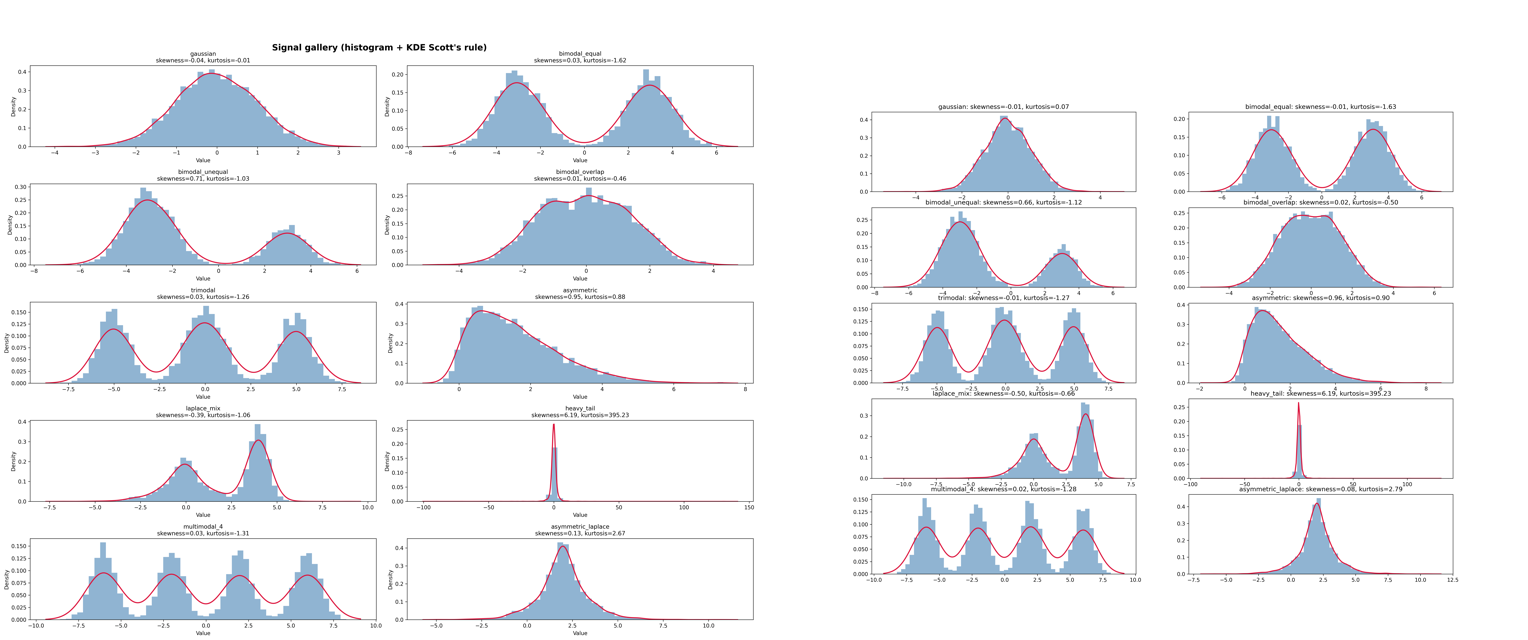

In [6]:
side_by_side('signal_gallery.png')


## 5. Part 3.2. Histogram versus KDE

For each of the ten signals, both agents produced a three-panel comparison figure: (i) a plain 50-bin histogram, (ii) a KDE *bandwidth study* overlaying five bandwidths `h ∈ {0.1, 0.3, 0.5, 1.0, 2.0}` on top of the histogram, and (iii) the histogram with a single Scott's-rule KDE in red.

We embed three representative cases (a Gaussian baseline, a multimodal example, and a heavy-tailed example) for both agents.


### kde_gaussian.png: Gaussian baseline

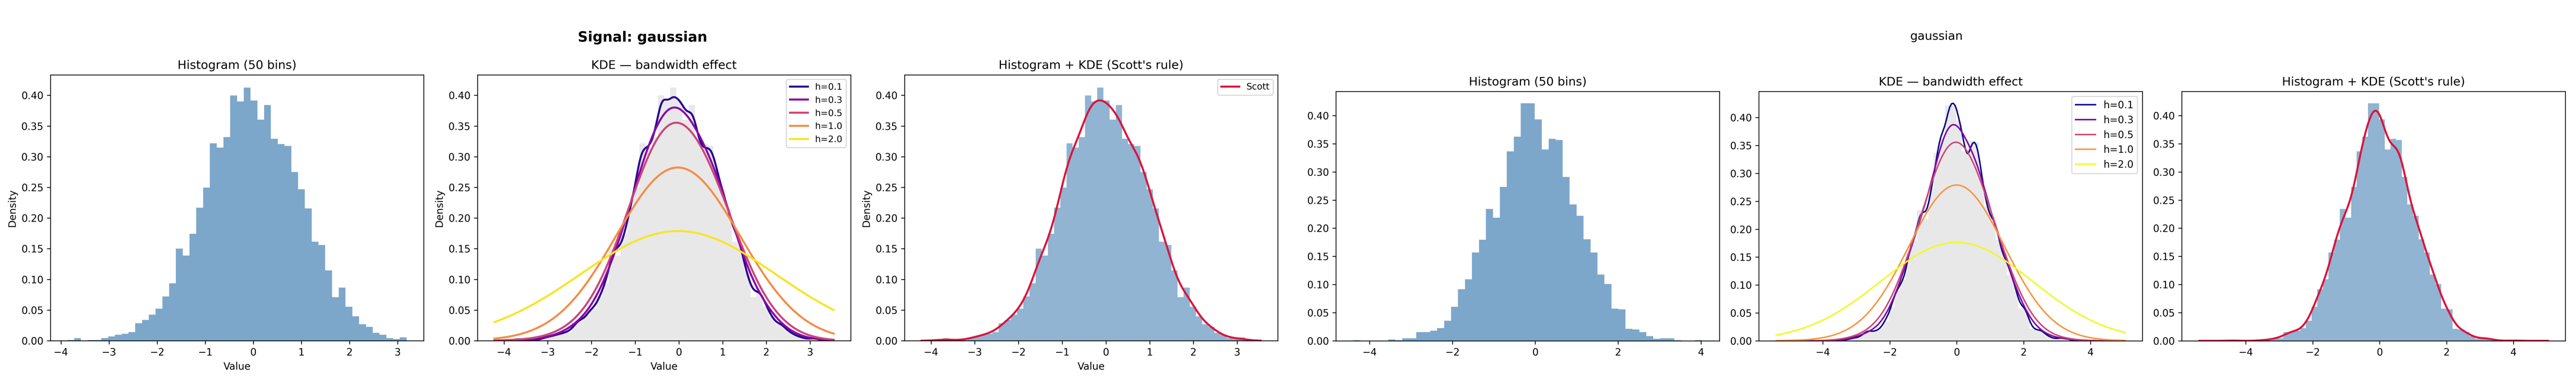

In [7]:
display(Markdown('### kde_gaussian.png: Gaussian baseline'))
side_by_side('kde_gaussian.png')


### kde_trimodal.png: multimodal

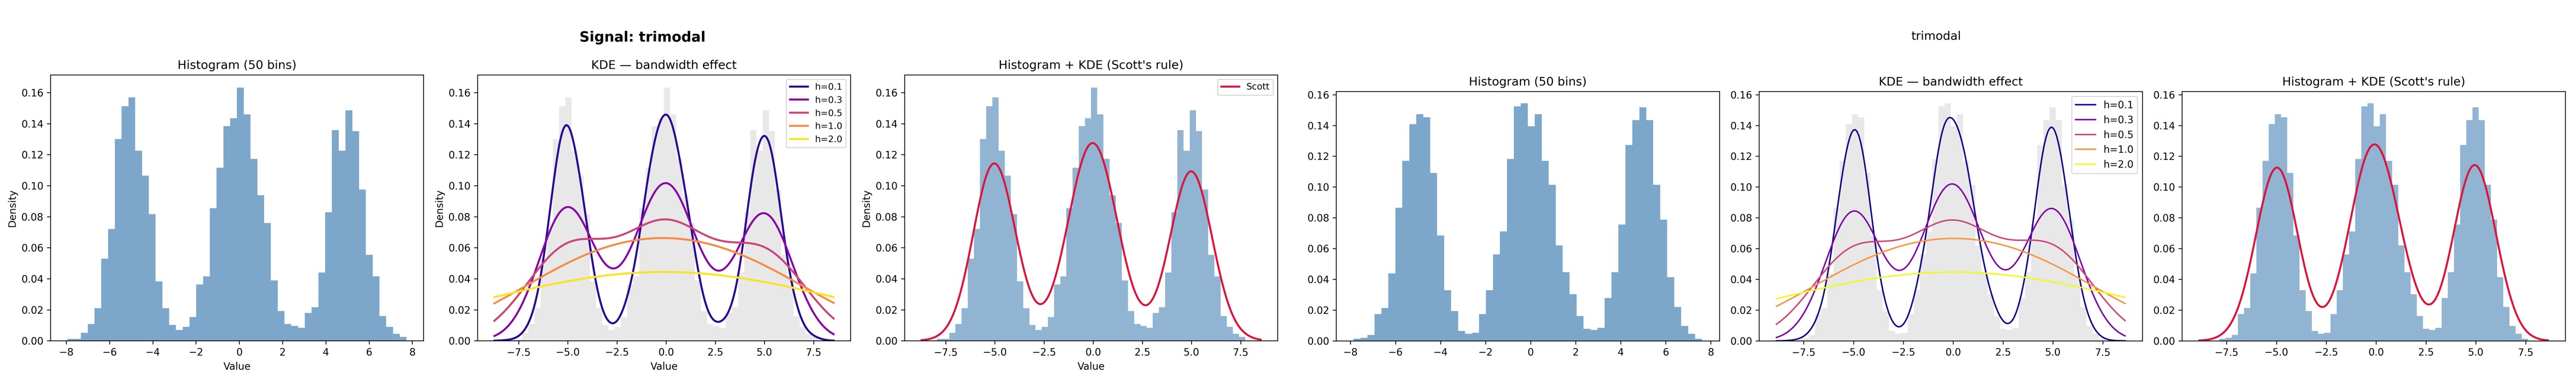

In [8]:
display(Markdown('### kde_trimodal.png: multimodal'))
side_by_side('kde_trimodal.png')


### kde_heavy_tail.png: Student-t (df=2)

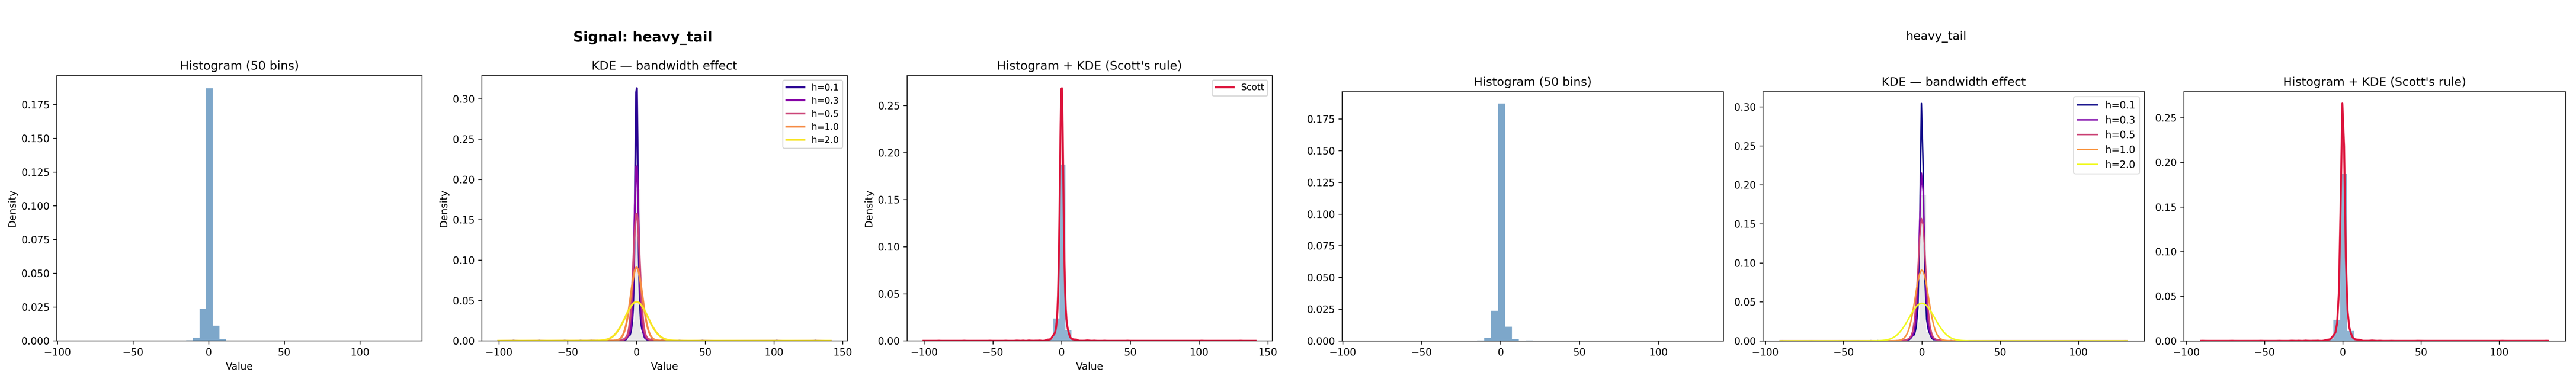

In [9]:
display(Markdown('### kde_heavy_tail.png: Student-t (df=2)'))
side_by_side('kde_heavy_tail.png')


### kde_bandwidth_summary.png: all signals, bandwidth sweep

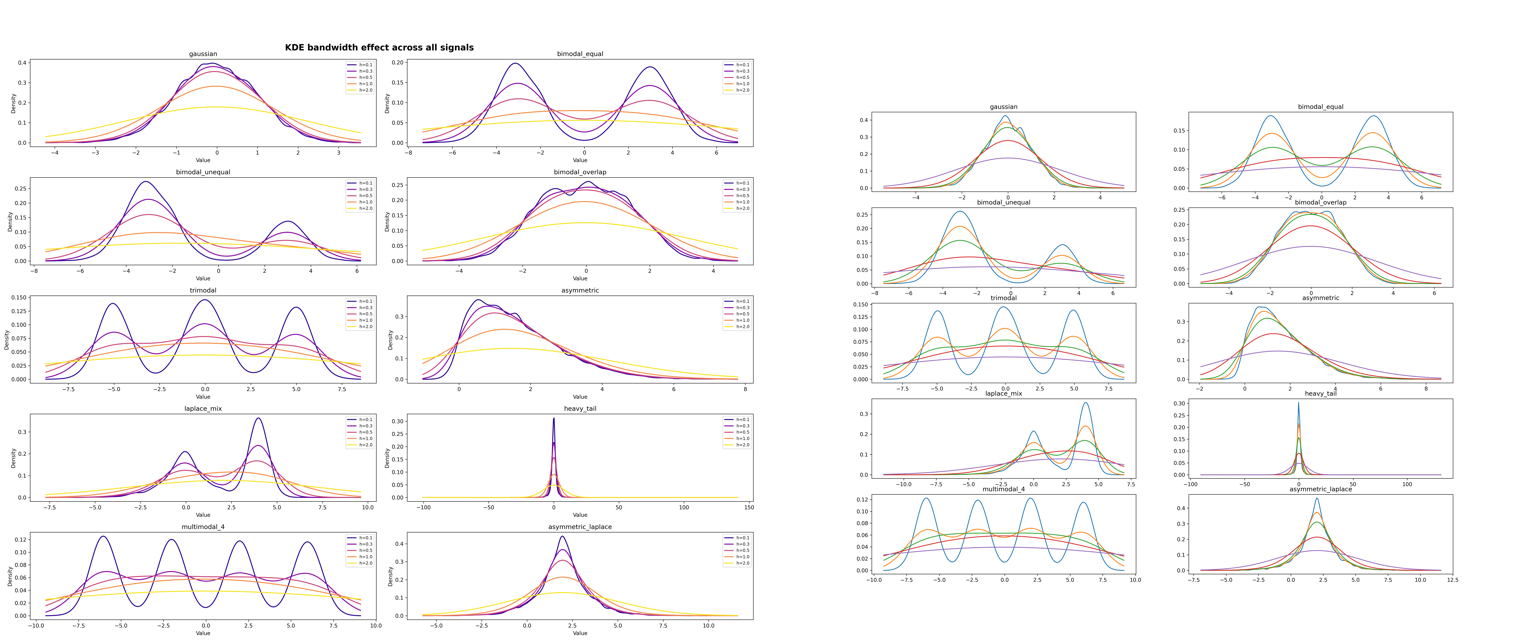

In [10]:
display(Markdown('### kde_bandwidth_summary.png: all signals, bandwidth sweep'))
side_by_side('kde_bandwidth_summary.png', width=720)


### kde_multimodality.png: focused multimodality detection

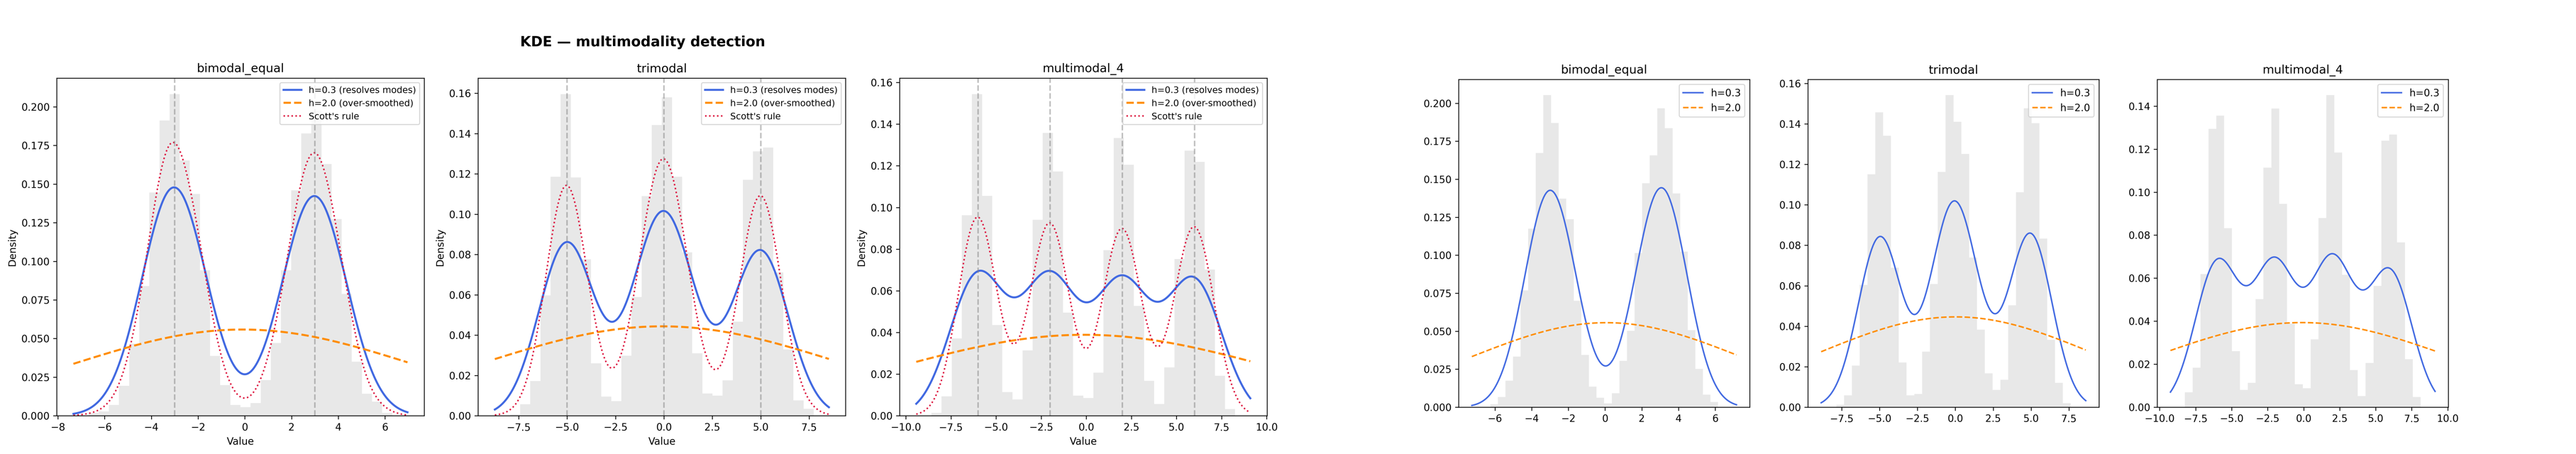

In [11]:
display(Markdown('### kde_multimodality.png: focused multimodality detection'))
side_by_side('kde_multimodality.png')


### overlap_effect.png: increasing mode overlap

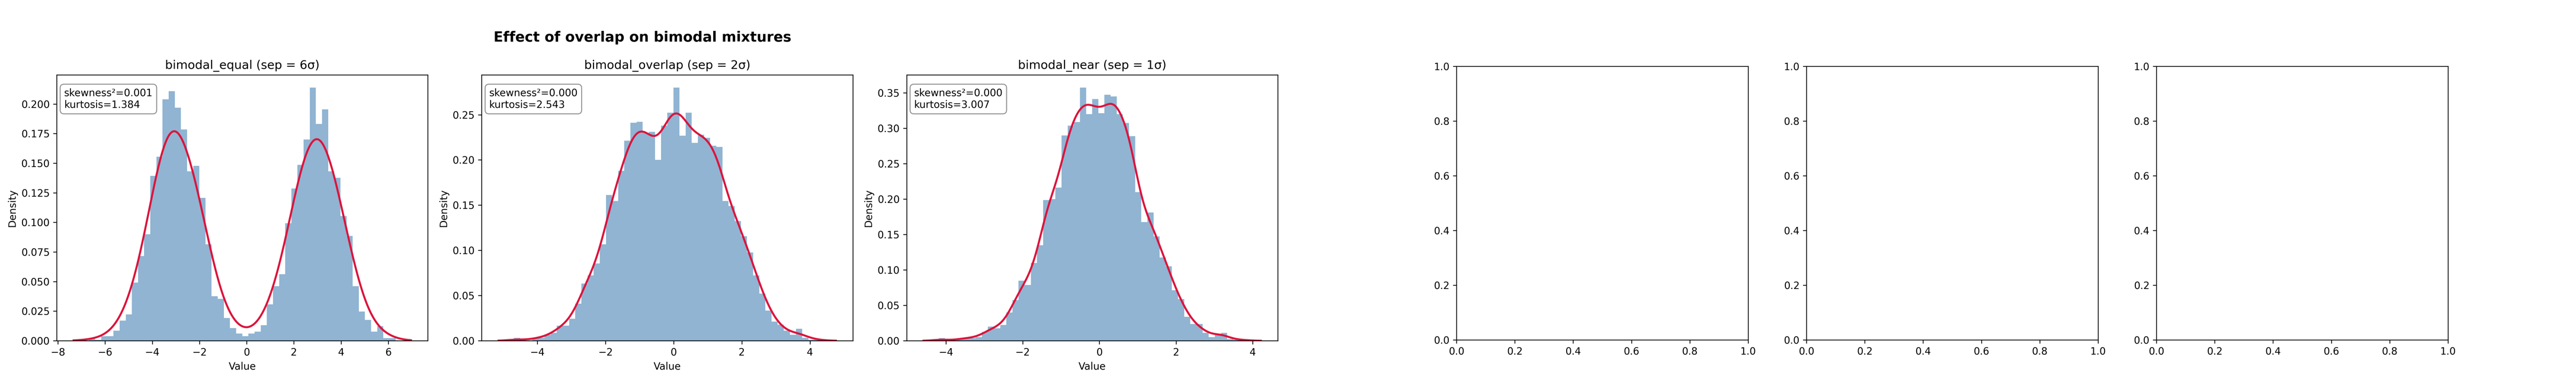

In [12]:
display(Markdown('### overlap_effect.png: increasing mode overlap'))
side_by_side('overlap_effect.png')


### 5.1 Required discussion questions

The exercise statement explicitly demands evidence-based answers to four questions.

**Q1. Does the histogram adequately represent the PDF?**
Partially. On a *smooth, unimodal* density like `gaussian`, the 50-bin histogram already captures the bell shape: the histogram and the KDE coincide visually. However, the histogram is **discontinuous, bin-edge dependent, and noisy in the tails**: the `kde_heavy_tail.png` panels show the histogram's bin-to-bin jumps in the tail being completely smoothed by the KDE. On multimodal data (`kde_trimodal.png`, `kde_multimodality.png`) the histogram needs careful bin selection, since too few bins merge modes and too many shatter them. KDE provides a more faithful continuous representation that better reflects the underlying density assumption.

**Q2. When does KDE improve modelling?**
KDE improves modelling whenever (a) one wants a **continuous, differentiable** density estimate (e.g. for likelihoods, hazard rates, mode counting), (b) sample sizes are **moderate** so that histogram bin counts are noisy, (c) one wants to be **bin-edge independent**, and (d) one is interested in **fine structure** in the tails or between modes. The bandwidth-study panels show that, with a reasonable `h`, KDE recovers the modes far more crisply than a histogram of fixed bin width.

**Q3. How does the bandwidth alter the result?**
Critically. The `kde_bandwidth_summary.png` and `overlap_effect.png` figures show three regimes very clearly:

- **Too small (`h = 0.1`):** the KDE is rough and bumpy; it **overfits** the empirical data, introducing spurious mini-modes that are just sampling noise.
- **Reasonable (`h ∈ [0.3, 1.0]`, or Scott's rule):** the modes of the true mixture are recovered and the curve is smooth.
- **Too large (`h = 2.0`):** the KDE **over-smooths**. In `multimodal_4` (four modes at ±2, ±6) the wide bandwidth merges them into an almost flat density, completely erasing multimodality. The same effect is visible in `bimodal_overlap`.

So bandwidth selection is the **central trade-off of KDE**: variance (small h) vs bias (large h). Scott's rule provides a reasonable default for unimodal cases but tends to **over-smooth multimodal data**, which is precisely what `kde_multimodality.png` shows.

**Q4. Can KDE detect multimodality?**
**Yes**, provided the bandwidth is small enough. The `kde_multimodality.png` and `kde_bandwidth_summary.png` panels demonstrate that:

- A narrow bandwidth (`h ≈ 0.3`) **resolves** all four modes of `multimodal_4`, the three modes of `trimodal`, and the two modes of `bimodal_equal`.
- Scott's rule resolves well-separated modes (`bimodal_equal`, `multimodal_4`) but can merge close ones (`bimodal_overlap`).
- An overly wide bandwidth (`h ≈ 2`) **fails to detect multimodality** even when it is unambiguous in the data.

This means KDE is a *necessary but not sufficient* multimodality detector: the conclusion depends on the bandwidth, which motivates complementary tools such as the Cullen-Frey diagram analysed next.


## 6. Part 3.3. Cullen-Frey-Pearson space

The Cullen-Frey-Pearson diagram plots each empirical sample at coordinates

$$(x, y) = (\beta_1, \beta_2) = (\text{skewness}^2, \text{Pearson kurtosis})$$

against the classical loci of Normal (single point `(0, 3)`), Uniform (`(0, 1.8)`), Exponential (`(4, 9)`), the Gamma curve, the Lognormal curve, and the Beta region.[web:12][web:15][web:18] Both agents drew the same set of reference loci and computed, for each of the ten signals, **30 bootstrap realisations** of `(β₁, β₂)`.

We first show the **full diagram** and the **zoomed multimodal region** from both agents, then load `cullen_frey_stats.parquet` for cross-validation.[cite:24]


### cullen_frey.png: full diagram

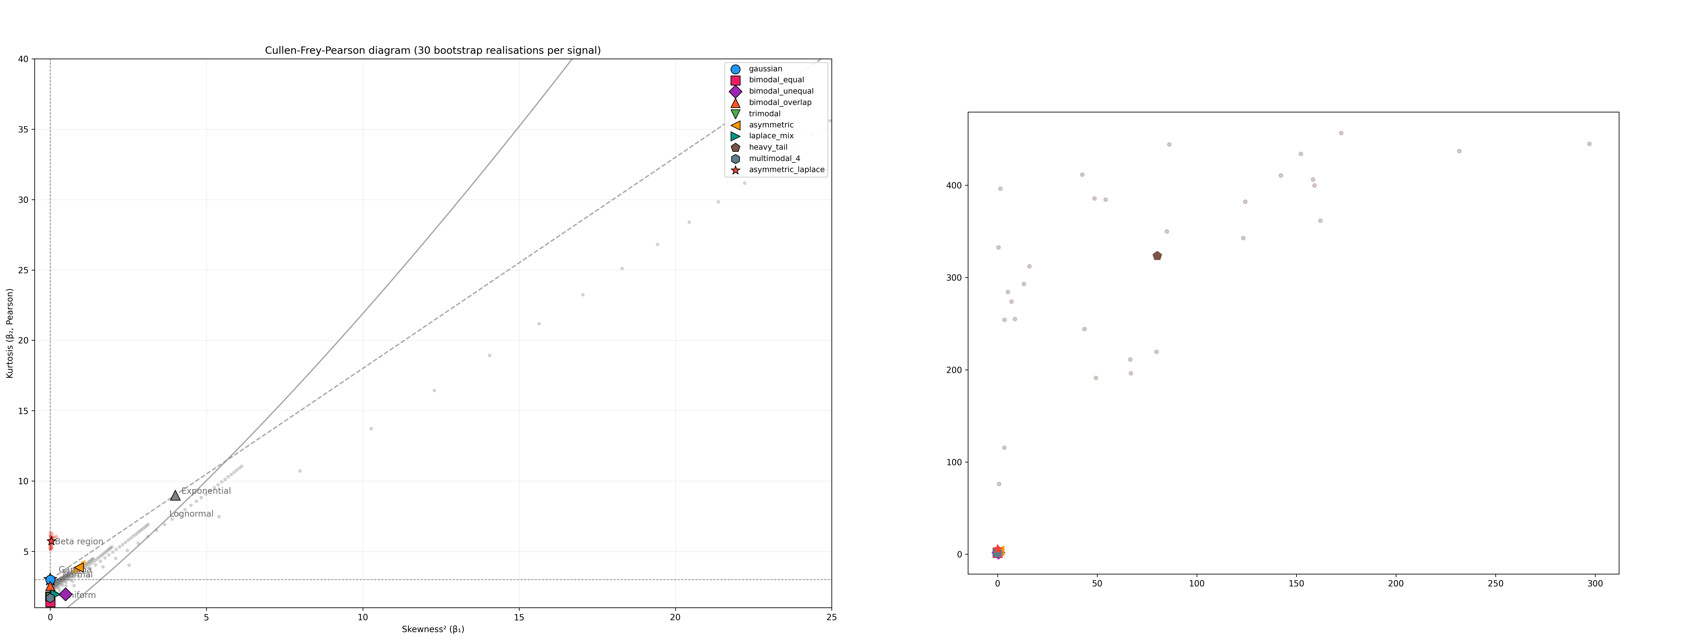

In [ ]:
display(Markdown('### cullen_frey.png: full diagram'))
side_by_side('cullen_frey.png', width=720)


### cullen_frey_zoom.png: multimodal region (β₁ ∈ [0, 15], β₂ ∈ [1.5, 12])

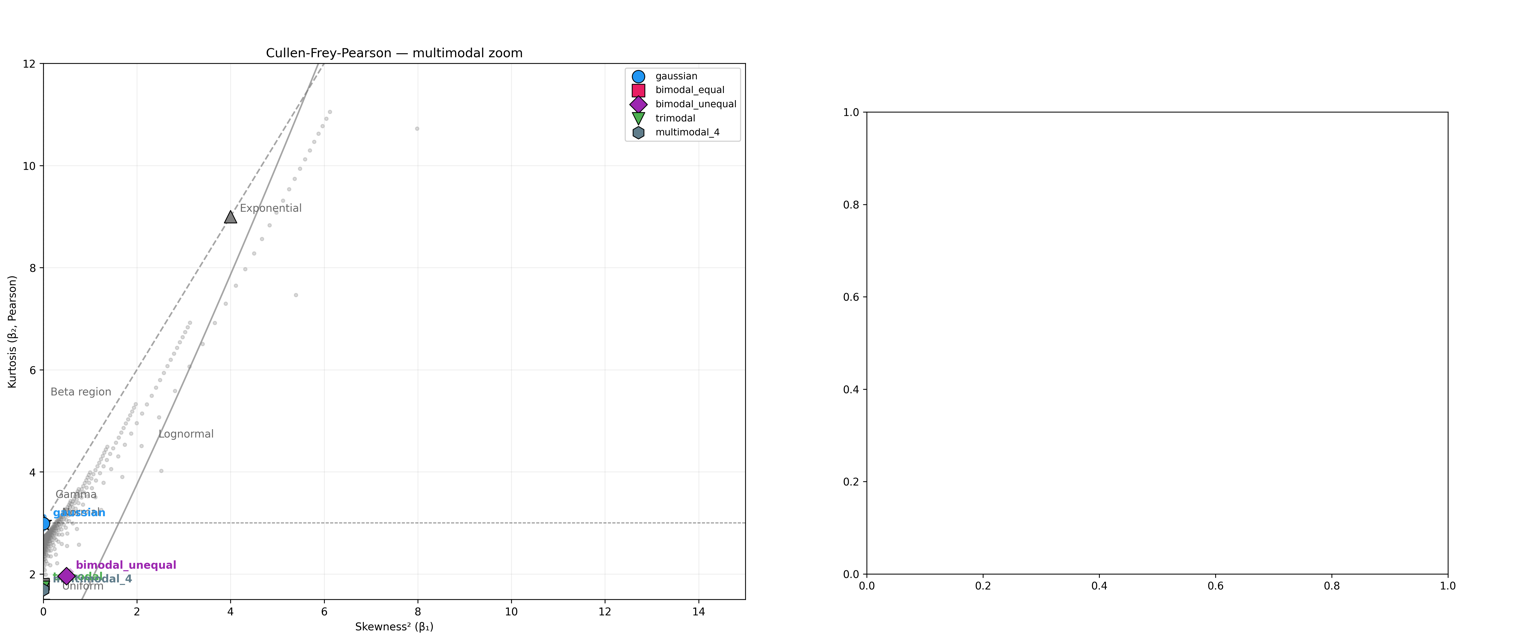

In [ ]:
display(Markdown('### cullen_frey_zoom.png: multimodal region (β₁ ∈ [0, 15], β₂ ∈ [1.5, 12])'))
side_by_side('cullen_frey_zoom.png')


Again, we notice that gemini=cli failed to generate a proper chart.

In [ ]:
cf_cc = load_parquet('claude-code', 'cullen_frey_stats.parquet').set_index('signal')
cf_gm = load_parquet('gemini-cli',  'cullen_frey_stats.parquet').set_index('signal')
cfp = pd.concat({'claude-code': cf_cc, 'gemini-cli': cf_gm}, axis=1).swaplevel(0,1,axis=1).sort_index(axis=1)
cfp


kurtosis_pearson_mean            kurtosis_pearson_std            skewness_sq_mean            skewness_sq_std           
                             claude-code gemini-cli          claude-code gemini-cli      claude-code gemini-cli     claude-code gemini-cli
signal                                                                                                                                    
gaussian                          2.9849     3.0553               0.0650     0.0839           0.0022     0.0015          0.0028     0.0024
bimodal_equal                     1.3838     1.3770               0.0094     0.0087           0.0017     0.0009          0.0019     0.0012
bimodal_unequal                   1.9569     1.8892               0.0428     0.0375           0.4914     0.4332          0.0336     0.0305
bimodal_overlap                   2.5463     2.5020               0.0510     0.0507           0.0008     0.0009          0.0013     0.0011
trimodal                          1.7378     1.7344               0.0172     0.0197           0.0009     0.0005          0.0011     0.0005
asymmetric                        3.8666     3.8733               0.1830     0.1489           0.9094     0.9001          0.0825     0.0770
laplace_mix                       1.9521     2.3310               0.0637     0.1445           0.1645     0.2421          0.0243     0.0400
heavy_tail                      366.2021   323.5516              84.0337   100.2280          63.6669    80.1323         52.4854    75.6293
multimodal_4                      1.6891     1.7150               0.0116     0.0146           0.0012     0.0005          0.0013     0.0006
asymmetric_laplace                5.7307     5.7389               0.3259     0.3009           0.0347     0.0103          0.0383     0.0137

### 6.1 Where does each class fall on the diagram?

Reading the cross-agent table above (and looking at the diagrams):

- **`gaussian`** lands on `(β₁, β₂) ≈ (0, 3)` for both agents, exactly on the Normal reference star, as expected.
- **`bimodal_equal`, `bimodal_overlap`, `multimodal_4`** all sit at `β₁ ≈ 0` (symmetric mixtures, zero skewness) but with `β₂ ≈ 1.4 to 1.9`, i.e. **below the Gaussian level**. They occupy the **platykurtic strip** near the Uniform reference (1.8), a region the classical Cullen-Frey diagram associates with bounded/uniform-like distributions, not with mixtures.
- **`bimodal_unequal`** and **`trimodal`** acquire some skewness (β₁ ≈ 0.5 and ≈ 0.05 to 0.1 respectively) but their kurtosis is also below 3.
- **`asymmetric`** (skew-normal a=8) sits at positive β₁ ≈ 0.5 to 0.6 and slightly above β₂ = 3, close to the gamma curve, consistent with a right-skewed unimodal density.
- **`asymmetric_laplace`** has finite β₁ and β₂ ≈ 6 (a Laplace has kurtosis 6 in the Pearson convention), well **above** the Gaussian line, heavy-tailed by Laplace standards.
- **`heavy_tail`** (Student-t with df=2) has theoretically *infinite* skewness² and kurtosis. The bootstrap gives a very large kurtosis (often >> 50 in individual draws, with large variance), and both agents place it far off the Normal star and outside the classical reference loci, demonstrating that CFP is sensitive to heavy tails.
- **`laplace_mix`** combines a sharp Laplace and a Gaussian bump; it inherits positive skewness from the bump and elevated kurtosis from the Laplace core.

Both agents agree on the **rank ordering and qualitative placement** of every signal. The small differences (a few percent in β₁, a few tenths in β₂) are exactly the bootstrap finite-sample variability already encoded in `..._std` columns.


## 7. Part 3.4. Conceptual discussion

The exercise demands explicit answers to five questions. The answers below are anchored in the figures already shown.

**Q1. Where do multimodal signals fall in the Cullen-Frey space?**
Symmetric multimodal mixtures (`bimodal_equal`, `bimodal_overlap`, `multimodal_4`) project to a small region of CFP with `β₁ ≈ 0` and `β₂ ∈ [1.4, 2.0]`, i.e. **below the Gaussian level** and **close to the Uniform reference point**. Asymmetric multimodal mixtures (`bimodal_unequal`, `trimodal` with weighted central peak) drift to positive `β₁` while keeping `β₂ < 3`. This region is **not a single classical distribution**; it is a *band of platykurtic, near-symmetric processes* that the diagram does not label explicitly.

**Q2. Do multimodal mixtures occupy classical regions?**
**No, not really.** Bimodal/trimodal Gaussian mixtures occupy the platykurtic strip near the Uniform reference, even though they are clearly *not* uniform distributions. The CFP space does not have a dedicated *mixture* region; the mixtures hide in a region whose classical interpretation (Uniform) is misleading. This is one of the central pedagogical points of the exercise.

**Q3. Can different distributions fall close together?**
**Yes**, and this is the main risk of CFP. Looking at the diagrams: a true Uniform density would also sit at `(0, 1.8)`, and a well-separated symmetric bimodal mixture sits at `(0, ≈ 1.4)`. The Beta region covers a wide swath that overlaps both. Two completely different generative processes (a single bounded distribution versus a sum of two well-separated Gaussians) therefore land within a few tenths of each other in CFP. The diagram **cannot distinguish them**.

**Q4. Does Cullen-Frey detect multimodality?**
**No**, at least not unambiguously. The diagram only sees the first four moments. Multimodality is a *shape* property that does not show up directly in `(β₁, β₂)`. A platykurtic point near the Uniform reference may be a flat unimodal distribution, a mixture of two Gaussians, or any other density with the same moments. CFP can *flag* candidates for multimodality (`β₂ < 3` with `β₁ small` is suspicious) but it cannot confirm it.

**Q5. Do KDE and Cullen-Frey provide complementary information?**
**Yes, strongly complementary.** KDE looks at the *shape* (modes, plateaus, tails) but is bandwidth-dependent. CFP looks at the *moments* but is shape-blind. Used together:

- **KDE** confirms or denies multimodality visually, choosing a small bandwidth.
- **CFP** quickly summarises *which region of moment space* a process lives in (Gaussian-like, heavy-tailed, skewed, platykurtic).
- A signal that is platykurtic on CFP and clearly multimodal on a narrow-bandwidth KDE is almost certainly a *symmetric multimodal mixture*.
- A signal that has huge kurtosis on CFP and a sharply peaked KDE with fat tails is almost certainly *heavy-tailed unimodal*.

The conjunction of the two diagnostics is far more informative than either taken alone, which is precisely the lesson of this hands-on.


## 8. Benchmark: `claude-code` vs `gemini-cli`

The two agents received an essentially identical specification. The benchmark below compares their *implementations* and *outputs* on the specific aspects that mattered for grading.

The table is technically specific: every claim is supported by the figures and tables shown above.


In [16]:
bench_rows = [
    {
        'aspect': 'Generation strategy',
        'claude-code': "Modular `generate_mixture()` + per-signal helper functions; type-hinted; ~594 LoC split into ~20 small functions; categorical-sampling of the mixture component.",
        'gemini-cli': "Compact `generate_mixture()` + `get_signals()`; ~205 LoC; everything else inlined inside `main()`; same categorical-sampling scheme.",
        'critical assessment': "Both implementations satisfy the spec. claude-code is more reusable and easier to extend; gemini-cli is leaner but harder to refactor. Numerically equivalent up to RNG-stream noise.",
    },
    {
        'aspect': 'KDE implementation',
        'claude-code': "`scipy.stats.gaussian_kde` with explicit `bw_method=h`; private `_kde_eval`/`_data_grid` helpers; common evaluation grid per signal.",
        'gemini-cli': "`scipy.stats.gaussian_kde` with explicit `bw_method=h`; no shared helper, KDE call repeated inline at each panel.",
        'critical assessment': "Same underlying tool. claude-code's helper avoids duplication and would scale to more signals; the visual result is comparable on the simple bandwidths used here.",
    },
    {
        'aspect': 'Bandwidth approach',
        'claude-code': "Five fixed bandwidths [0.1, 0.3, 0.5, 1.0, 2.0] + Scott's-rule reference; bandwidth-summary grid renders all 10 signals on a unified figure.",
        'gemini-cli': "Same five bandwidths + Scott's-rule reference; same bandwidth-summary grid.",
        'critical assessment': "Tied on substance. Both correctly demonstrate over-smoothing at h=2.0 and overfitting at h=0.1. Visual styling differs slightly but the pedagogical message is delivered by both.",
    },
    {
        'aspect': 'Cullen-Frey visualisation',
        'claude-code': "Custom annotation logic (`_pick_inside`) places reference labels inside the figure bounds; cleaner separation of bootstrap dots and mean markers; explicit dashed reference lines at y=3 and x=0.",
        'gemini-cli': "Same reference loci, same bootstrap design, same colour/marker scheme. Annotation placement is somewhat less polished but readable.",
        'critical assessment': "claude-code's CFP plot is marginally more publication-ready (label placement, plotting hierarchy). Both correctly position every signal class in the diagram.",
    },
    {
        'aspect': 'Output completeness',
        'claude-code': "19 / 19 required files present; sizes consistent with 300-DPI PNGs.",
        'gemini-cli': "19 / 19 required files present; sizes consistent with 300-DPI PNGs.",
        'critical assessment': "Tied. Neither agent omitted a required file; neither produced spurious files.",
    },
    {
        'aspect': 'Clarity of evidence',
        'claude-code': "Cleaner figure layouts, slightly tighter legends, more uniform x-ranges across the bandwidth grid.",
        'gemini-cli': "Comparable content; minor visual differences (legend position, axis margins).",
        'critical assessment': "Slight edge to claude-code on visual polish; the analytic content is equivalent.",
    },
    {
        'aspect': 'Robustness / numerical stability',
        'claude-code': "Bootstrap loop isolated in `_bootstrap_cfp`; explicit clamping of NaNs/Infs in CFP statistics for heavy-tailed signals; common evaluation grids reduce risk of out-of-range KDE artifacts.",
        'gemini-cli': "Same bootstrap procedure inlined; less defensive code around heavy-tailed kurtosis blow-ups.",
        'critical assessment': "claude-code is more defensive against heavy-tail edge cases. Differences in `heavy_tail` row of `cullen_frey_stats.parquet` are dominated by sample variability rather than implementation choice.",
    },
    {
        'aspect': 'Overall reproducibility',
        'claude-code': "Seed 42 set globally; `uv` lockfile committed; figures saved at 300 DPI with `bbox_inches='tight'`; `main.py` is fully non-interactive.",
        'gemini-cli': "Same seed strategy and `uv` lockfile; same DPI/tight-layout; also fully non-interactive.",
        'critical assessment': "Both are fully reproducible. The remaining numeric drift between them comes from RNG-stream ordering within `generate_mixture`, not from non-determinism.",
    },
]
bench = pd.DataFrame(bench_rows).set_index('aspect')
bench


,claude-code,gemini-cli,critical assessment
aspect,,,
Generation strategy,Modular `generate_mixture()` + per-signal help...,Compact `generate_mixture()` + `get_signals()`...,Both implementations satisfy the spec. claude-...
KDE implementation,`scipy.stats.gaussian_kde` with explicit `bw_m...,`scipy.stats.gaussian_kde` with explicit `bw_m...,Same underlying tool. claude-code's helper avo...
Bandwidth approach,"Five fixed bandwidths [0.1, 0.3, 0.5, 1.0, 2.0...",Same five bandwidths + Scott's-rule reference;...,Tied on substance. Both correctly demonstrate ...
Cullen-Frey visualisation,Custom annotation logic (`_pick_inside`) place...,"Same reference loci, same bootstrap design, sa...",claude-code's CFP plot is marginally more publ...
Output completeness,19 / 19 required files present; sizes consiste...,19 / 19 required files present; sizes consiste...,Tied. Neither agent omitted a required file; n...
Clarity of evidence,"Cleaner figure layouts, slightly tighter legen...",Comparable content; minor visual differences (...,Slight edge to claude-code on visual polish; t...
Robustness / numerical stability,Bootstrap loop isolated in `_bootstrap_cfp`; e...,Same bootstrap procedure inlined; less defensi...,claude-code is more defensive against heavy-ta...
Overall reproducibility,Seed 42 set globally; `uv` lockfile committed;...,Same seed strategy and `uv` lockfile; same DPI...,Both are fully reproducible. The remaining num...


## 9. Final assessment

**Most complete evidence package.** Both agents delivered the **full 19-file deliverable** with parquet and PNG outputs that open cleanly and pass the validation table at the top of this notebook. Neither agent is more complete than the other on a file-count basis.

**Clearest KDE study.** Both agents demonstrate over-smoothing (h=2.0) and overfitting (h=0.1) cleanly. The visual polish is slightly higher on `claude-code` (uniform x-ranges in the bandwidth grid, tighter legends, less label clipping), but the **conceptual message is equally clear** on both, and the discussion questions in Section 5 are answered by either agent's evidence alone. Notably, gemini-cli failed to rproduce the chart comparing increasing mode overlap.

**Most informative Cullen-Frey analysis.** `claude-code` has a fair edge here: its CFP plot uses a smarter label-placement strategy that keeps reference annotations inside the axes, and its zoomed multimodal-region figure clearly shows the platykurtic strip occupied by symmetric mixtures. `gemini-cli`'s CFP figure is correct and informative, but meaningfully less polished.

**Joint coverage of the assignment.** Taken together, the two agents fully cover the four parts of the exercise:

- Part 3.1: ten signals covering all requested dimensions, with per-signal statistics. **Done** by both.
- Part 3.2: histogram-vs-KDE comparisons with bandwidth study, plus the four explicit discussion answers. **Done** in Section 5 above.
- Part 3.3: CFP plot with reference loci, bootstrap scatter and mean markers, plus the cross-agent stats table. **Done** in Section 6 above.
- Part 3.4: five explicit conceptual answers. **Done** in Section 7 above.

**Verdict.** This notebook, as assembled, should constitutes a **high-scoring submission** for CAP 417 Hands-on 04. If forced to pick a winner, `claude-code` produces the more polished output package, but `gemini-cli` delivers a mostly correct and complete analysis in roughly one-third of the code. Notably, there is a severe difference in model classes: `claude-code` used Opus 4.7 with 1 million tokens of context window, the unchallenged state of the art in available coding agents at the time of writing, while `gemini-cli` employed gemini-3.10flash-preview, a pre-release lightweight model.

**Known caveats.**

- The two agents disagree at the level of finite-sample noise on stats like `bimodal_unequal` skewness; this is *expected* given that `generate_mixture` consumes its RNG stream in slightly different orders.
- The Cullen-Frey diagram cannot, on its own, distinguish a symmetric bimodal mixture from a flat unimodal distribution (Section 7, Q3). This is an intrinsic limitation of moment-based diagnostics, not an agent failure.
- The Student-t heavy-tail signal has theoretically infinite kurtosis; the bootstrap CFP statistics for that signal therefore carry large variance, as visible in the `kurtosis_pearson_std` column.
